In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/14
    print("準備完了！このまま下のセルを実行できます。")

# 第14章 サンプリング (Sampling)
## 14.3 ランジュバンサンプリング (Langevin Sampling)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第14章「サンプリング」第3節「ランジュバンサンプリング」に対応する完全な解説・数式導出・図版再現・Python実装です。

---

### 本節の構成と小節一覧
- **14.3.1 エネルギーベースモデル (Energy-based models)**: 未正規化確率分布とエネルギー関数、分配関数 $Z(\mathbf{w})$ の計算困難性、スコア関数 $s(x) = \nabla_x \ln p(x)$ による正規化定数の消去（式 14.29 〜 14.31）
- **14.3.2 尤度最大化 (Maximizing the likelihood)**: 対数尤度勾配の展開、ポジティブフェーズ（データ点エネルギーの引き下げ）とネガティブフェーズ（モデルサンプルエネルギーの引き上げ）、Figure 14.13 の完全再現（式 14.32 〜 14.34, Figure 14.13）
- **14.3.3 ランジュバン動力学 (Langevin dynamics)**: 連続時間ランジュバン拡散過程、オイラー・丸山法による離散化 (ULA: Unadjusted Langevin Algorithm)、メトロポリス調整ランジュバン法 (MALA: Metropolis-Adjusted Langevin Algorithm)、多峰性・孤立モードにおける限界とアニーリング型ランジュバン（式 14.35 〜 14.38, Figure 14.14）


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# リポジトリルートを検索パスに追加
repo_root = Path.cwd().parent if Path.cwd().name == "14" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
from common.langevin_sampling import (
    EnergyBasedModel1D,
    unadjusted_langevin_algorithm,
    metropolis_adjusted_langevin_algorithm,
    annealed_langevin_dynamics,
    generate_figure_14_13,
    generate_figure_14_14,
)

setup_style()
print("Setup complete. Section 14.3 Langevin Sampling module loaded successfully.")


Setup complete. Section 14.3 Langevin Sampling module loaded successfully.


---

### 14.3.1 エネルギーベースモデル (Energy-based models)

深層学習における多くの生成モデル（GAN、変分自己符号化器、正規化フローなど）は、サンプリングを容易にするために明示的な潜在変数空間や可逆変換を設計します。これに対し、**エネルギーベースモデル (Energy-Based Model, EBM)** は、データ空間 $x \in \mathbb{R}^D$ 上の任意のスカラー関数（エネルギー関数）$E(x; \mathbf{w})$ を用いて、確率分布を次のように極めて柔軟に定義します：
$$
p(x; \mathbf{w}) = \frac{1}{Z(\mathbf{w})} \exp(-E(x; \mathbf{w})) \tag{14.29}
$$
ここで $\mathbf{w}$ はニューラルネットワーク等の学習可能パラメータであり、$Z(\mathbf{w})$ は**分配関数 (partition function)** と呼ばれる正規化定数です：
$$
Z(\mathbf{w}) = \int \exp(-E(x; \mathbf{w})) \, dx \tag{14.30}
$$

#### 1. 分配関数の計算困難性 (Intractability of Partition Function)
$E(x; \mathbf{w})$ が非線形な深層ニューラルネットワークである場合、高次元空間（例えば画像データ $D \sim 10^6$）における全空間積分 式 (14.30) を解析的に解くことは不可能であり、グリッド数値積分も次元の呪いにより不可能です。したがって、尤度 $p(x; \mathbf{w})$ そのものを直接評価することはできません。

#### 2. スコア関数による分配関数の消去 (The Score Function)
しかし、$x$ に関する対数確率密度の勾配である**スコア関数 (score function)** を考えると、驚くべき簡約が起こります：
$$
s(x) \equiv \nabla_x \ln p(x; \mathbf{w}) = \nabla_x \left[ -E(x; \mathbf{w}) - \ln Z(\mathbf{w}) \right]
$$
分配関数 $Z(\mathbf{w})$ はパラメータ $\mathbf{w}$ のみに依存し、$x$ には一切依存しない定数であるため、$\nabla_x \ln Z(\mathbf{w}) = 0$ となります。したがって：
$$
\nabla_x \ln p(x; \mathbf{w}) = -\nabla_x E(x; \mathbf{w}) \tag{14.31}
$$
すなわち、**未正規化のエネルギー関数の勾配を計算するだけで、目標確率分布のスコア関数（確率密度が増加する方向ベクトル）が厳密に求まる**という決定的な利点が得られます。


In [2]:
# 1D EBM のスコア関数と数値分配関数の確認
# 二次エネルギー: E(x) = 0.5 * w * x^2 (分散 sigma^2 = 1/w のガウス分布)
w_param = np.array([2.0])
ebm_1d = EnergyBasedModel1D(
    energy_fn=lambda x, w: 0.5 * w[0] * (x ** 2),
    grad_x_energy_fn=lambda x, w: w[0] * x,
    grad_w_energy_fn=lambda x, w: 0.5 * (x ** 2).reshape(-1, 1),
)

x_eval = np.array([-1.5, 0.0, 2.0])
score_vals = ebm_1d.score(x_eval, w_param)
z_val = ebm_1d.compute_partition_function(w_param)

print("=== Energy-Based Model 1D Demo ===")
print(f"w: {w_param[0]}")
print(f"Points x: {x_eval}")
print(f"Score s(x) = -w * x: {score_vals}")
print(f"Numerical Partition Function Z: {z_val:.5f} (True sqrt(2*pi/w) = {np.sqrt(2 * np.pi / w_param[0]):.5f})")


=== Energy-Based Model 1D Demo ===
w: 2.0
Points x: [-1.5  0.   2. ]
Score s(x) = -w * x: [ 3. -0. -4.]
Numerical Partition Function Z: 1.77245 (True sqrt(2*pi/w) = 1.77245)


---

### 14.3.2 尤度最大化 (Maximizing the likelihood)

エネルギーベースモデルのパラメータ $\mathbf{w}$ を訓練データ $\mathcal{D} = \{x^{(n)}\}_{n=1}^N$ に対して最尤推定することを考えます。

#### 1. 対数尤度勾配の厳密な数式展開
1つの観測データ点 $x$ に対する対数尤度のパラメータ勾配を計算します：
$$
\nabla_{\mathbf{w}} \ln p(x; \mathbf{w}) = \nabla_{\mathbf{w}} \left( -E(x; \mathbf{w}) - \ln Z(\mathbf{w}) \right) = -\nabla_{\mathbf{w}} E(x; \mathbf{w}) - \nabla_{\mathbf{w}} \ln Z(\mathbf{w}) \tag{14.32}
$$
ここで第2項の分配関数の対数微分を展開します：
$$
\begin{aligned}
\nabla_{\mathbf{w}} \ln Z(\mathbf{w}) &= \frac{1}{Z(\mathbf{w})} \nabla_{\mathbf{w}} Z(\mathbf{w}) \\
&= \frac{1}{Z(\mathbf{w})} \nabla_{\mathbf{w}} \int \exp(-E(x'; \mathbf{w})) \, dx' \\
&= \frac{1}{Z(\mathbf{w})} \int \nabla_{\mathbf{w}} \exp(-E(x'; \mathbf{w})) \, dx' \\
&= \frac{1}{Z(\mathbf{w})} \int \exp(-E(x'; \mathbf{w})) \left( -\nabla_{\mathbf{w}} E(x'; \mathbf{w}) \right) \, dx' \\
&= -\int \frac{\exp(-E(x'; \mathbf{w}))}{Z(\mathbf{w})} \nabla_{\mathbf{w}} E(x'; \mathbf{w}) \, dx' \\
&= -\int p(x'; \mathbf{w}) \nabla_{\mathbf{w}} E(x'; \mathbf{w}) \, dx' \\
&= -\mathbb{E}_{p(x'; \mathbf{w})}\left[ \nabla_{\mathbf{w}} E(x'; \mathbf{w}) \right] \tag{14.33}
\end{aligned}
$$
この結果を式 (14.32) に代入すると、対数尤度勾配の美しい基本公式が得られます：
$$
\nabla_{\mathbf{w}} \ln p(x; \mathbf{w}) = -\nabla_{\mathbf{w}} E(x; \mathbf{w}) + \mathbb{E}_{p(x'; \mathbf{w})}\left[ \nabla_{\mathbf{w}} E(x'; \mathbf{w}) \right] \tag{14.34}
$$

#### 2. ポジティブフェーズとネガティブフェーズ (Positive & Negative Phases)
データセット全体 $\mathcal{D}$ に関する平均対数尤度勾配は次のようになります：
$$
\nabla_{\mathbf{w}} \mathcal{L}(\mathbf{w}) = \underbrace{-\frac{1}{|\mathcal{D}|} \sum_{x \in \mathcal{D}} \nabla_{\mathbf{w}} E(x; \mathbf{w})}_{\text{Positive Phase (データによる引き下げ)}} + \underbrace{\mathbb{E}_{x \sim p_{\mathcal{M}}}\left[ \nabla_{\mathbf{w}} E(x; \mathbf{w}) \right]}_{\text{Negative Phase (モデルサンプルによる引き上げ)}}
$$
- **ポジティブフェーズ (Positive Phase)**: 実際の訓練データ点 $x \in \mathcal{D}$ において、エネルギー $E(x; \mathbf{w})$ を引き下げる（確率密度を高める）方向にパラメータを更新します。
- **ネガティブフェーズ (Negative Phase)**: 現在のモデル分布 $p_{\mathcal{M}}(x; \mathbf{w})$ から生成されたサンプルにおいて、エネルギー $E(x; \mathbf{w})$ を引き上げる（確率密度を下げる）方向に更新します。
- これにより、データが存在する領域のエネルギーのみが低くなり、データが存在しない領域のエネルギーは押し上げられ、モデル分布全体が正規化を保ちながらデータ分布に整合していきます。

#### Figure 14.13: エネルギーベースモデルの最尤学習
下図は、データ分布 $p_{\mathcal{D}}(x)$（赤破線）、モデル分布 $p_{\mathcal{M}}(x)$（青破線）、およびエネルギー関数 $E(x, \mathbf{w})$（緑実線）の関係を示しています。
データ点（赤丸）では下向き緑矢印 $\downarrow$ によりエネルギーが引き下げられ、モデルサンプル（青丸）では上向き緑矢印 $\uparrow$ によりエネルギーが引き上げられます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_13_energy_based_training.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_13_energy_based_training.png


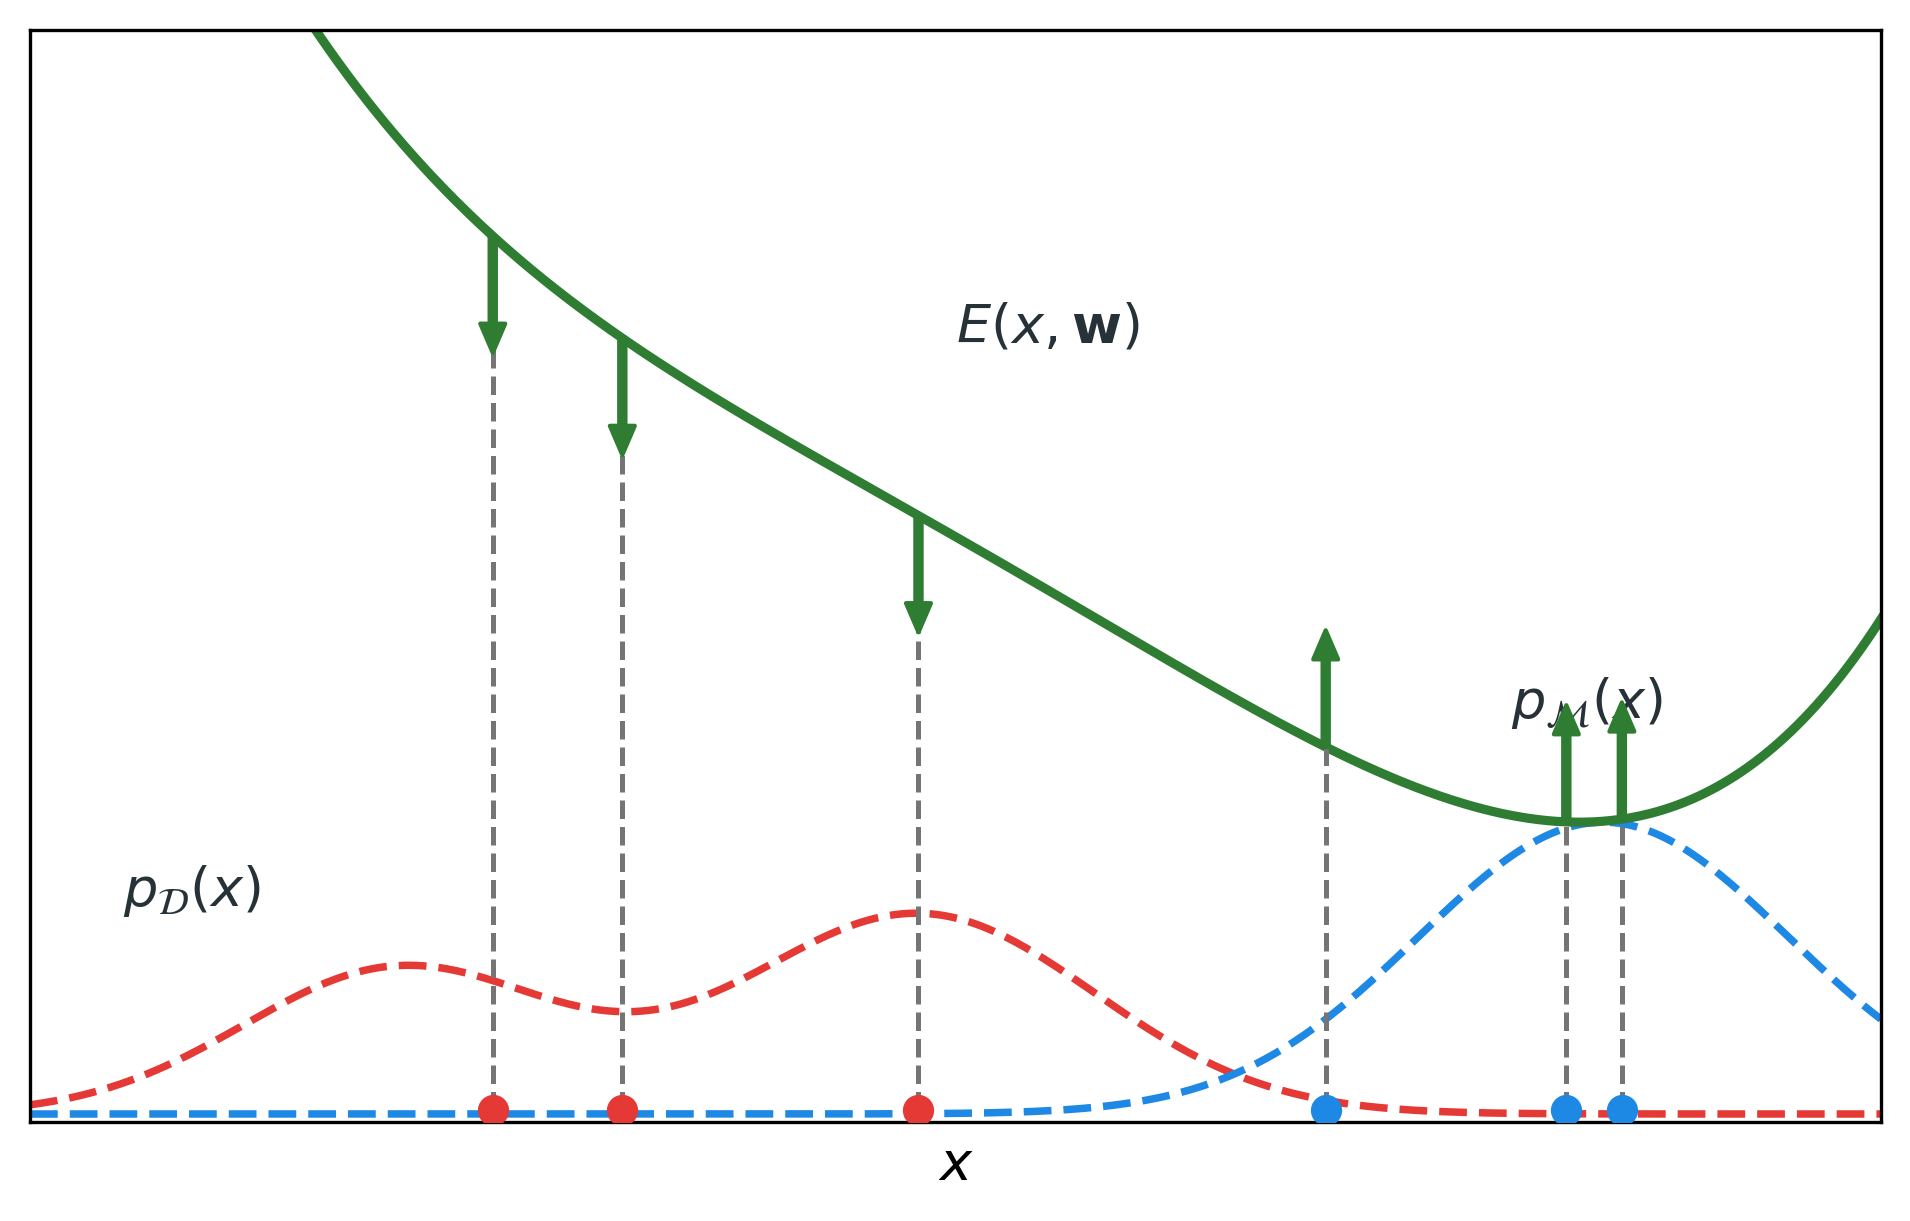

Positive Phase Grad: -0.4964
Negative Phase Grad: 1.0209
Total Grad dL/dw:    0.5245 (Positive gradient pushes w up to match true variance 1.0)


In [3]:
# Figure 14.13 の生成と描画
fig14_13 = generate_figure_14_13()
plt.show()

# ポジティブフェーズとネガティブフェーズの勾配計算デモ
rng = np.random.RandomState(42)
true_data = rng.normal(loc=0.0, scale=1.0, size=5000)
# モデルの現在パラメータ w = 0.5 (分散 2.0 と過大評価している状態)
current_w = np.array([0.5])
model_samples = rng.normal(loc=0.0, scale=np.sqrt(1.0 / current_w[0]), size=5000)

grad_res = ebm_1d.compute_log_likelihood_gradient(true_data, model_samples, current_w)
print(f"Positive Phase Grad: {grad_res['positive_phase'][0]:.4f}")
print(f"Negative Phase Grad: {grad_res['negative_phase'][0]:.4f}")
print(f"Total Grad dL/dw:    {grad_res['total_grad'][0]:.4f} (Positive gradient pushes w up to match true variance 1.0)")


---

### 14.3.3 ランジュバン動力学 (Langevin dynamics)

式 (14.34) のネガティブフェーズを評価するためには、現在のモデル分布 $p(x; \mathbf{w})$ からサンプルを生成する必要があります。しかし、分配関数 $Z(\mathbf{w})$ は未知です。
この問題を解決するのが、**スコア関数 $\nabla_x \ln p(x)$ のみを用いてサンプリングを行うランジュバン動力学 (Langevin Dynamics)** です。

#### 1. 連続時間ランジュバン拡散過程
物理学において、流体中の微粒子のブラウン運動（ゆらぎと摩擦）を記述する過減衰ランジュバン方程式（確率微分方程式, SDE）は次のように与えられます：
$$
dz(t) = \frac{1}{2} \nabla_z \ln p(z(t)) \, dt + dW(t) \tag{14.35}
$$
ここで $W(t)$ は標準ブラウン運動（ウィーナー過程）であり、$dW(t) \sim \mathcal{N}(0, dt \mathbf{I})$ です。
この確率過程の確率密度分布の時間発展はフォッカー・プランク方程式（Fokker-Planck equation）に支配され、$t \to \infty$ の定常分布（不変分布）は厳密に目標分布 $p(z)$ に収束します。

#### 2. 無調整ランジュバンアルゴリズム (Unadjusted Langevin Algorithm: ULA)
連続時間過程 (14.35) を有限の時間刻み幅 $\epsilon > 0$ でオイラー・丸山法（Euler-Maruyama method）により離散化すると、以下の反復式が得られます：
$$
z^{(\tau+1)} = z^{(\tau)} + \frac{\epsilon}{2} \nabla_z \ln p(z^{(\tau)}) + \sqrt{\epsilon} \boldsymbol{\eta}^{(\tau)}, \quad \boldsymbol{\eta}^{(\tau)} \sim \mathcal{N}(0, \mathbf{I}) \tag{14.36}
$$
- **第2項（ドリフト項）**: 勾配 $\nabla_z \ln p(z) = -\nabla_z E(z)$ に沿って、エネルギーが低く確率密度が高い領域へと決定論的に引っ張られます。
- **第3項（拡散項）**: 等方的なガウスノイズを加えることで、極小値（モード）に捕らわれず、確率分布全体を探索します。
- 通常のメトロポリス法（ランダムウォーク）と異なり、勾配情報を用いて典型集合へと効率的に進むため、高次元空間における探索効率が飛躍的に向上します。
- **課題**: 有限のステップサイズ $\epsilon > 0$ による離散化誤差（バイアス）が存在し、定常分布が真の $p(z)$ からわずかにずれます。

#### 3. メトロポリス調整ランジュバン法 (Metropolis-Adjusted Langevin Algorithm: MALA)
離散化誤差を完全に補正するため、ULAの1ステップを**メトロポリス・ヘイスティングス法の提案分布**として用います（Roberts & Tweedie, 1996）：
$$
q(z^* \mid z) = \mathcal{N}\left(z^* \;\middle|\; z + \frac{\epsilon}{2} \nabla_z \ln p(z), \, \epsilon \mathbf{I}\right) \tag{14.37}
$$
この提案に対する受理確率は、通常のMH受理確率式 (14.20) に従います：
$$
A(z^*, z) = \min\left(1, \frac{p(z^*) q(z \mid z^*)}{p(z) q(z^* \mid z)}\right) \tag{14.38}
$$
棄却ステップを導入することにより、有限の $\epsilon$ であっても詳細釣り合いが厳密に満たされ、離散化バイアスがゼロになります。

#### Figure 14.14: 孤立した多峰性分布におけるランジュバン動力学の限界
ランジュバン動力学およびスコアベースサンプリングには、**孤立したモード（Multimodal with isolated modes）を横断できない**という根本的な限界が存在します。
下図に示すように、高密度領域（桃色領域）が低密度領域によって空間的に隔てられている場合、中間領域では確率密度 $p(z) \approx 0$ となり、スコア $\nabla_z \ln p(z) \approx 0$ となります。
そのため、勾配による駆動力が完全に失われ、純粋なガウスノイズのランダムウォークによる拡散のみで広大な低密度領域を渡りきる必要があります。これは実質的に不可能な時間を要し、サンプラーは初期値が位置した単一のモードに拘束（Mode Collapse）されます。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/14/result/fig_14_14_multimodal_challenge.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_14_14_multimodal_challenge.png


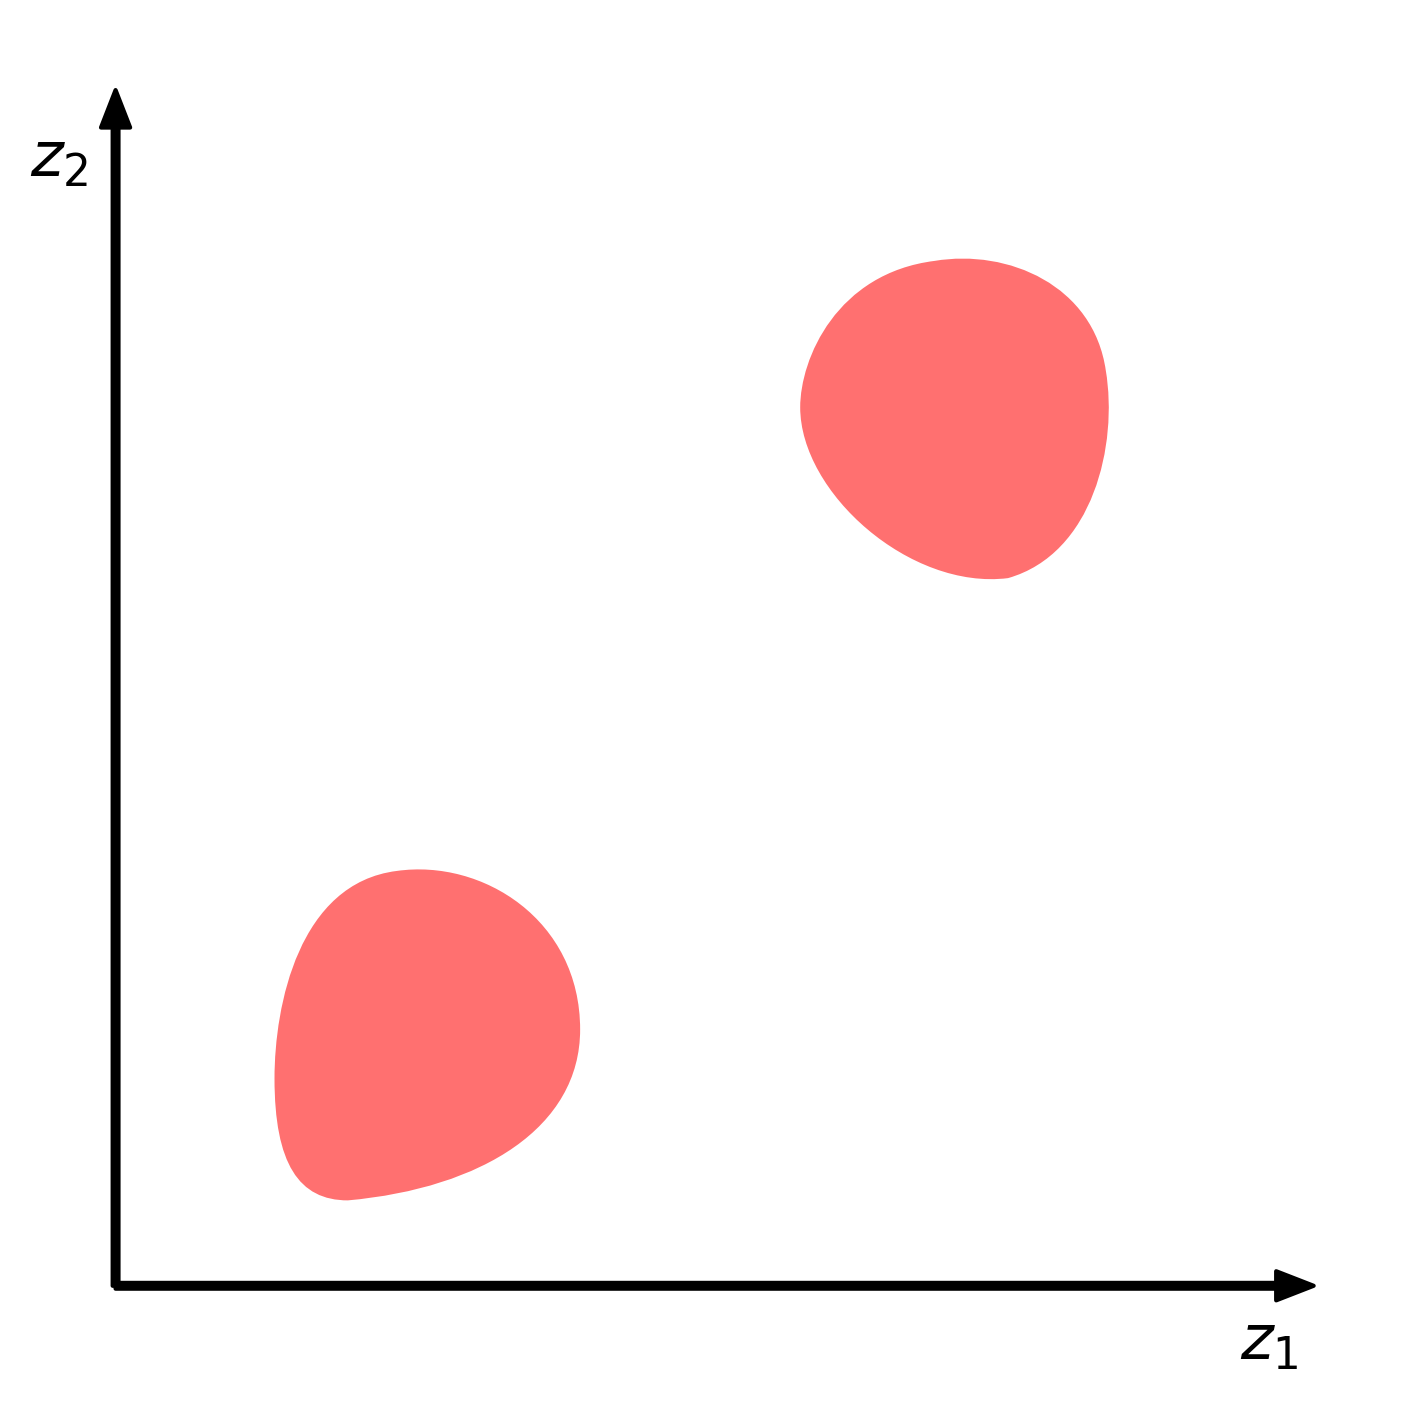

In [4]:
# Figure 14.14 の生成と描画
fig14_14 = generate_figure_14_14()
plt.show()


#### 4. ULA と MALA の比較検証
以下では、標準正規分布 $\mathcal{N}(0, 1)$ に対する ULA と MALA のサンプリング挙動を比較します。


ULA  Sample Mean: 0.0061, Var: 1.0436
MALA Sample Mean: 0.0101, Var: 0.9646, Acc Rate: 0.994


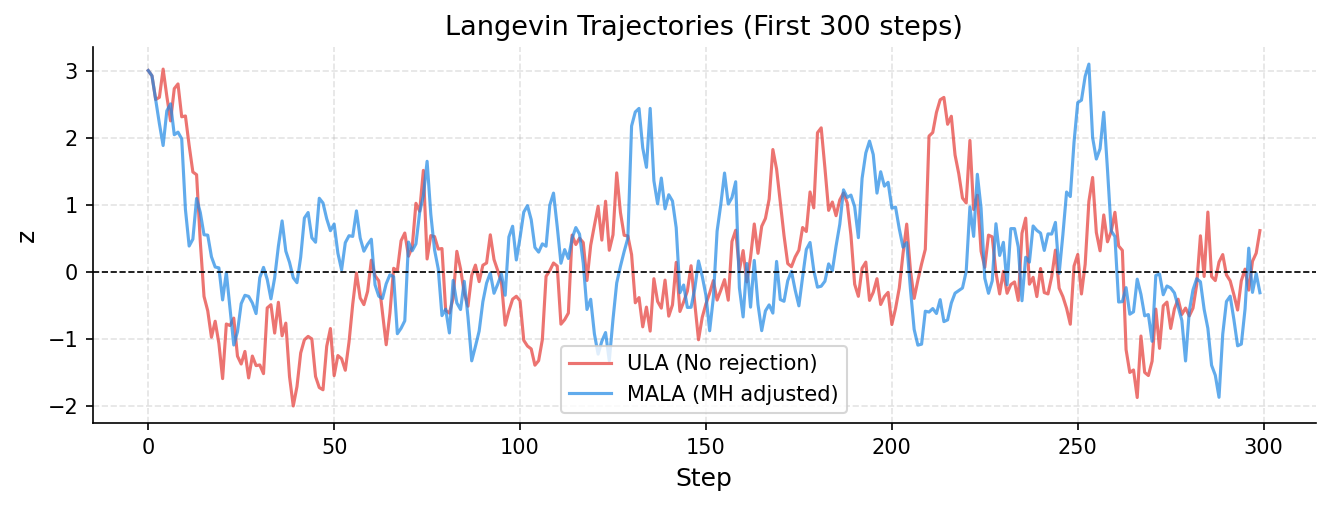

In [5]:
# ULA と MALA のサンプリング比較
target_log_p_gaussian = lambda z: -0.5 * (z[0] ** 2)
score_gaussian = lambda z: -z

init_pos = np.array([3.0])
step_eps = 0.20
n_steps = 5000

ula_res = unadjusted_langevin_algorithm(
    score_fn=score_gaussian,
    init_state=init_pos,
    step_size=step_eps,
    num_steps=n_steps,
    burn_in=1000,
    seed=42,
)

mala_res = metropolis_adjusted_langevin_algorithm(
    target_log_p=target_log_p_gaussian,
    score_fn=score_gaussian,
    init_state=init_pos,
    step_size=step_eps,
    num_steps=n_steps,
    burn_in=1000,
    seed=42,
)

print(f"ULA  Sample Mean: {np.mean(ula_res['samples']):.4f}, Var: {np.var(ula_res['samples']):.4f}")
print(f"MALA Sample Mean: {np.mean(mala_res['samples']):.4f}, Var: {np.var(mala_res['samples']):.4f}, Acc Rate: {mala_res['acceptance_rate']:.3f}")

# 軌跡の可視化
plt.figure(figsize=(9, 3.5), dpi=150)
plt.plot(ula_res['trajectory'][:300], label="ULA (No rejection)", alpha=0.7, color="#e53935")
plt.plot(mala_res['trajectory'][:300], label="MALA (MH adjusted)", alpha=0.7, color="#1e88e5")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title("Langevin Trajectories (First 300 steps)")
plt.xlabel("Step")
plt.ylabel("z")
plt.legend()
plt.tight_layout()
plt.show()


#### 5. アニーリング型ランジュバン動力学 (Annealed Langevin Dynamics)
Figure 14.14 の孤立モード問題を打破するために考案されたのが、**ノイズのスケールを幾何学的に変化させるアニーリング型ランジュバン動力学 (Song & Ermon, 2019)** です。
これは、目標分布に様々なスケールのガウスノイズを加えた平滑化分布列 $p_{\sigma_1}, p_{\sigma_2}, \dots, p_{\sigma_L}$（$\sigma_1 > \sigma_2 > \dots > \sigma_L$）を用意し：
1. 大きなノイズ $\sigma_1$ ではモード間の谷間が埋められ、チェーンはモード間を自在に行き来できる。
2. ノイズレベルを徐々に小さくしながらランジュバンサンプリングを継続することで、各モードの真の分布へと正確に収束していく。

このアニーリング型ランジュバン動力学こそが、近年の画像生成革命を牽引する**拡散モデル (Diffusion Models, 第20章)** の数学的基盤そのものです。


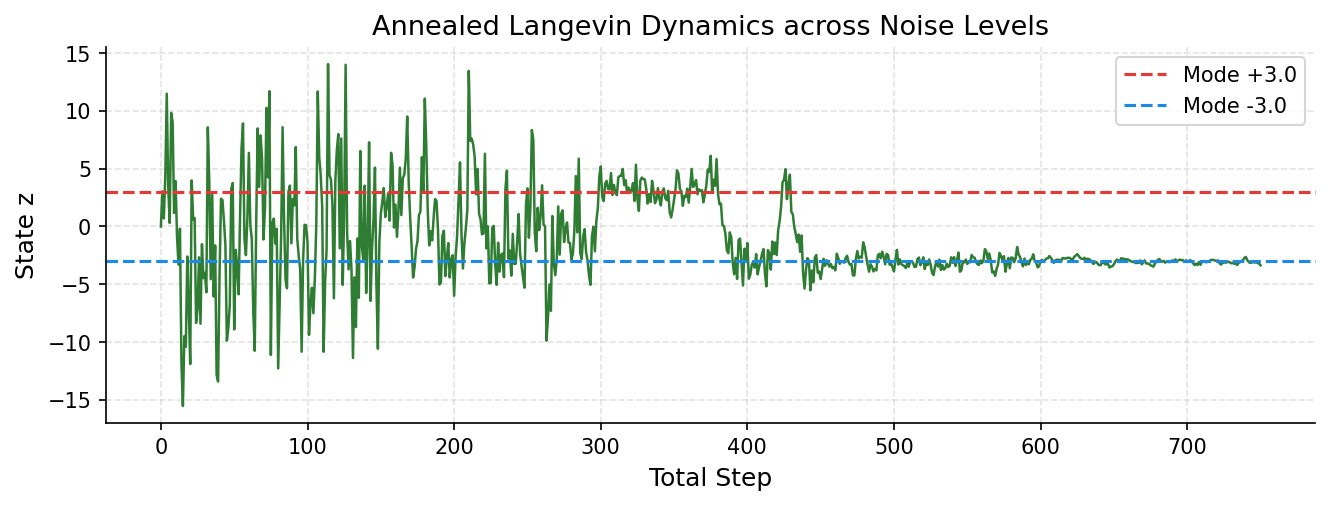

Final sampled state: -3.354 (Successfully converged to mode)


In [6]:
# アニーリング型ランジュバン動力学による多峰性分布の横断
# 目標分布: 2つの孤立モード x = -3.0 と x = +3.0
noise_schedule = [5.0, 2.5, 1.0, 0.4, 0.1]

def build_score_at_noise(sigma):
    def score_sigma(x):
        var = 0.04 + sigma ** 2
        g1 = np.exp(-0.5 * ((x - 3.0) ** 2) / var)
        g2 = np.exp(-0.5 * ((x + 3.0) ** 2) / var)
        return (g1 * (-(x - 3.0) / var) + g2 * (-(x + 3.0) / var)) / (g1 + g2 + 1e-12)
    return score_sigma

score_chain = [build_score_at_noise(s) for s in noise_schedule]

annealed_res = annealed_langevin_dynamics(
    score_fns=score_chain,
    sigmas=noise_schedule,
    init_state=np.array([0.0]),
    num_steps_per_level=150,
    step_size_factor=0.015,
    seed=42,
)

traj = annealed_res["trajectory"].flatten()
plt.figure(figsize=(9, 3.5), dpi=150)
plt.plot(traj, color="#2e7d32", linewidth=1.2)
plt.axhline(+3.0, color="#e53935", linestyle="--", label="Mode +3.0")
plt.axhline(-3.0, color="#1e88e5", linestyle="--", label="Mode -3.0")
plt.title("Annealed Langevin Dynamics across Noise Levels")
plt.xlabel("Total Step")
plt.ylabel("State z")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final sampled state: {annealed_res['final_sample'][0]:.3f} (Successfully converged to mode)")


---

### 14.3.4 まとめ (Summary and Perspectives)

1. **エネルギーベースモデル**: 分配関数 $Z(\mathbf{w})$ を正規化することなく、任意の非負関数 $\exp(-E(x; \mathbf{w}))$ で分布を定義できる。
2. **スコア関数**: $\nabla_x \ln p(x) = -\nabla_x E(x)$ により分配関数が完全に消去され、高次元空間での勾配計算が容易になる。
3. **最尤学習の2相構造**: 対数尤度勾配は、データ点でのエネルギーを引き下げるポジティブフェーズと、モデルサンプルのエネルギーを引き上げるネガティブフェーズの拮抗によって駆動される（Figure 14.13）。
4. **無調整ランジュバン (ULA)**: 確率微分方程式のオイラー・丸山離散化により、勾配ドリフトとガウス拡散を組み合わせて高速にサンプリングを行う。
5. **メトロポリス調整 (MALA)**: ULAの離散化バイアスをMH受理・棄却判定で補正し、厳密な定常分布を実現する。
6. **多峰性の限界と拡散モデル**: 孤立したモードではスコアが消失しランジュバンサンプリングが膠着する（Figure 14.14）。多重ノイズスケールによるアニーリングがこれを解決し、第20章「拡散モデル (Diffusion Models)」の理論的土台を形成する。
